### Torsion differential equation from construction science

We want to solve the Laplace differential equation with Neumann boundary conditions in the unit square:

$$
\Delta\Psi = 0 \quad\text{in }[0,1]\times[0,1],\qquad 
\frac{\partial\Psi}{\partial n} = y\,n_x - x\,n_y \quad\text{on }\partial\Omega
$$

In [1]:
# Importing libraries
import numpy as np
from numba import jit
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

### Discretisation
- Grid: $x_i=ih$, $y_j=jh$, $h=1/N$, $i,j=0,\dots,N$.
- $\Psi_{i,j}\approx\Psi(x_i,y_j)$.

### Interior (5‑point stencil)
For $1\le i,j\le N-1$:
$$\Psi_{i,j}=\frac14(\Psi_{i+1,j}+\Psi_{i-1,j}+\Psi_{i,j+1}+\Psi_{i,j-1}).$$

### Neumann boundaries (using ghost points)
The condition on each edge translates into a relation for a fictitious point outside; inserting into Laplace at the boundary gives the update.

- **Bottom** ($j=0$, $1\le i\le N-1$): $\partial_y\Psi=-x$ ⇒ ghost $(i,-1)$:
  $$\Psi_{i,0}=\frac14(\Psi_{i+1,0}+\Psi_{i-1,0}+2\Psi_{i,1}+2h x_i).$$
- **Top** ($j=N$, $1\le i\le N-1$): $\partial_y\Psi=-x$ ⇒ ghost $(i,N+1)$:
  $$\Psi_{i,N}=\frac14(\Psi_{i+1,N}+\Psi_{i-1,N}+2\Psi_{i,N-1}-2h x_i).$$
- **Left** ($i=0$, $1\le j\le N-1$): $\partial_x\Psi=y$ ⇒ ghost $(-1,j)$:
  $$\Psi_{0,j}=\frac14(2\Psi_{1,j}+\Psi_{0,j+1}+\Psi_{0,j-1}-2h y_j).$$
- **Right** ($i=N$, $1\le j\le N-1$): $\partial_x\Psi=y$ ⇒ ghost $(N+1,j)$:
  $$\Psi_{N,j}=\frac14(2\Psi_{N-1,j}+\Psi_{N,j+1}+\Psi_{N,j-1}+2h y_j).$$

### Corners (two ghosts)
- Bottom‑right $(N,0)$: $\Psi_{N,0}=\frac12(\Psi_{N-1,0}+\Psi_{N,1}+h)$.
- Top‑left $(0,N)$: $\Psi_{0,N}=\frac12(\Psi_{1,N}+\Psi_{0,N-1}-h)$.
- Top‑right $(N,N)$: $\Psi_{N,N}=\frac12(\Psi_{N-1,N}+\Psi_{N,N-1})$.
- Bottom‑left $(0,0)$ fixed to $0$ to remove the nullspace (Neumann problem ⇒ solution up to constant).

These equations define a linear system $A\mathbf{\Psi} = \mathbf{b}$ that can be solved in two different ways:

### 1. Iterative solution (Gauss–Seidel)
- Sweep the grid repeatedly, updating each point *in place* using the formulas above.
- Each update uses the most recent values of neighbours, accelerating convergence.
- Check convergence: $\max|\Psi^{\text{new}}-\Psi^{\text{old}}| < \text{tol}$.
- Stop when converged or after maximum iterations.

### 2. Direct sparse matrix solution
- Assemble the sparse matrix $A$ and right‑hand side $\mathbf{b}$ using exactly the same coefficients:
  - Interior: $[1,1,1,1,-4]$ with $b=0$
  - Boundaries: modified stencils with $2$ for the neighbour opposite the boundary, and $b$ containing the $2h$ terms
  - Corners: $[1,1,-2]$ with $b$ containing $\pm h$ where applicable
- The system is singular (Neumann problem). Remove the nullspace by eliminating the equation at $(0,0)$ (pinning $\Psi_{0,0}=0$).
- Solve the reduced system $A_{\text{red}}\mathbf{\Psi}_{\text{red}} = \mathbf{b}_{\text{red}}$ with a direct sparse solver.
- Reconstruct the full solution by inserting $\Psi_{0,0}=0$.

In [2]:
@jit(nopython = True, parallel = True)
def solve_laplace_neumann(N = 200, tol = 1e-7, max_iterations = 100_000):
    
    h = 1.0 / N
    x = np.linspace(0, 1, N + 1)
    y = x.copy()
    Psi = np.zeros((N + 1, N + 1))

    iteration = 0
    while iteration < max_iterations: # Safety by max_iterations

        Psi_old = Psi.copy() # To check convergence later

        # Interior points (i=1..N-1, j=1..N-1)
        for i in range(1, N):
            for j in range(1, N):
                Psi[i, j] = 0.25 * (Psi[i + 1, j] + Psi[i - 1, j] + Psi[i, j + 1] + Psi[i, j - 1])

        for i in range(1, N): # Bottom edge (j=0, i=1..N-1)
            Psi[i, 0] = 0.25 * (Psi[i + 1, 0] + Psi[i - 1, 0] + 2.0 * Psi[i, 1] + 2.0 * h * x[i])

        for i in range(1, N): # Top edge (j=N, i=1..N-1)
            Psi[i, N] = 0.25 * (Psi[i + 1, N] + Psi[i - 1, N] + 2.0 * Psi[i, N - 1] - 2.0 * h * x[i])

        for j in range(1, N): # Left edge (i=0, j=1..N-1)
            Psi[0, j] = 0.25 * (2.0 * Psi[1, j] + Psi[0, j + 1] + Psi[0, j - 1] - 2.0 * h * y[j])

        for j in range(1, N): # Right edge (i=N, j=1..N-1)
            Psi[N, j] = 0.25 * (2.0 * Psi[N - 1, j] + Psi[N, j + 1] + Psi[N, j - 1] + 2.0 * h * y[j])

        # Corners
        Psi[0, 0] = 0.0 # Fix one point to remove the nullspace (bottom‑left corner)
        Psi[N, 0] = 0.5 * (Psi[N - 1, 0] + Psi[N, 1] + h) # Bottom‑right (N, 0)
        Psi[0, N] = 0.5 * (Psi[1, N] + Psi[0, N - 1] - h) # Top‑left (0, N)
        Psi[N, N] = 0.5 * (Psi[N - 1, N] + Psi[N, N - 1]) # Top‑right (N, N)

        # Check convergence
        max_diff = np.max(np.abs(Psi - Psi_old))
        if max_diff < tol:
            print(f"Converged after {iteration}")
            break

        iteration += 1
        if iteration == max_iterations: # Max number of iterations reached. Exit the while-loop
            print(f"Max number of iterations reached: {max_iterations}")

    return (x, y, Psi)

def plot(x, y, Psi):
    X, Y = np.meshgrid(x, y, indexing = 'ij')
    plt.figure(figsize = (8, 6))
    contour = plt.contourf(X, Y, Psi, levels = 200, cmap = 'berlin')
    plt.colorbar(contour, label = r'$\Psi(x, y)$')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Solution of Laplace equation with Neumann boundary conditions')
    plt.show()

    return None

In [3]:
x, y, Psi1 = solve_laplace_neumann()
Psi1

Converged after 50370


array([[ 0.00000000e+00, -1.00182908e-04, -3.50731657e-04, ...,
        -4.98838717e-01, -4.99089317e-01, -4.99189551e-01],
       [ 1.00182908e-04, -1.54397166e-17, -2.36886759e-04, ...,
        -4.93952612e-01, -4.94189551e-01, -4.94289784e-01],
       [ 3.50731657e-04,  2.36886759e-04, -2.05591837e-17, ...,
        -4.89189851e-01, -4.89426789e-01, -4.89540685e-01],
       ...,
       [ 4.98838717e-01,  4.93952612e-01,  4.89189851e-01, ...,
        -3.79470760e-17, -4.76281326e-03, -9.64886838e-03],
       [ 4.99089317e-01,  4.94189551e-01,  4.89426789e-01, ...,
         4.76281326e-03, -3.79470760e-17, -4.89971710e-03],
       [ 4.99189551e-01,  4.94289784e-01,  4.89540685e-01, ...,
         9.64886838e-03,  4.89971710e-03, -3.77302356e-17]],
      shape=(201, 201))

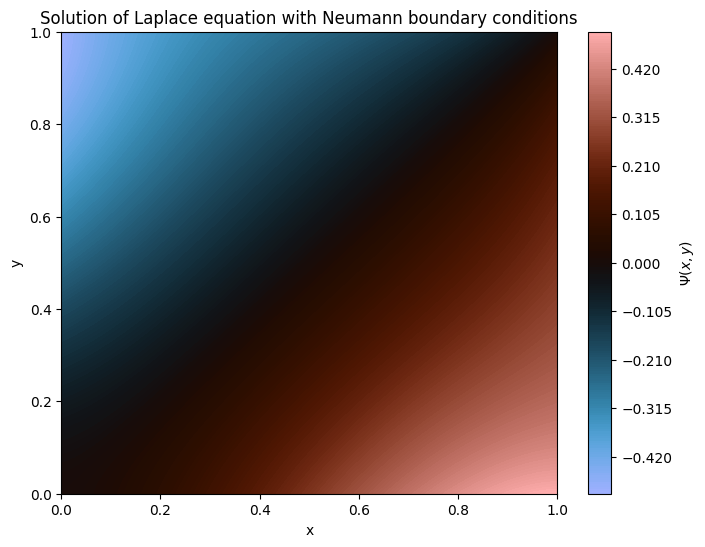

In [4]:
plot(x, y, Psi1)

In [5]:
# Alternative implementation using sparse matrices
def solve_laplace_neumann_sparse(N = 200):

    h = 1.0 / N
    x = np.linspace(0, 1, N + 1)
    y = x.copy()

    idx = lambda i, j: i * (N + 1) + j # Lambda function for indexing

    N1squared = (N + 1) ** 2
    A = lil_matrix((N1squared, N1squared))
    b = np.zeros(N1squared)

    # Bulding the sparse matrix
    for i in range((N + 1)):
        for j in range((N + 1)):
            k = idx(i, j)
            xi = x[i]
            yj = y[j]

            # Interior
            if 0 < i < N and 0 < j < N:
                A[k, idx(i + 1, j)] = 1.0
                A[k, idx(i - 1, j)] = 1.0
                A[k, idx(i, j + 1)] = 1.0
                A[k, idx(i, j - 1)] = 1.0
                A[k, k] = - 4.0
                b[k] = 0.0

            # Bottom edge (j = 0), not corners
            elif j == 0 and 0 < i < N:
                A[k, idx(i + 1, j)] = 1.0
                A[k, idx(i - 1, j)] = 1.0
                A[k, idx(i, j + 1)] = 2.0
                A[k, k] = - 4.0
                b[k] = - 2.0 * h * xi

            # Top edge (j=nx-1), not corners
            elif j == N and 0 < i < N:
                A[k, idx(i + 1, j)] = 1.0
                A[k, idx(i - 1, j)] = 1.0
                A[k, idx(i, j - 1)] = 2.0
                A[k, k] = - 4.0
                b[k] = 2.0 * h * xi

            # Left edge (i = 0), not corners
            elif i == 0 and 0 < j < N:
                A[k, idx(i + 1, j)] = 2.0
                A[k, idx(i, j + 1)] = 1.0
                A[k, idx(i, j - 1)] = 1.0
                A[k, k] = - 4.0
                b[k] = 2.0 * h * yj

            # Right edge (i = nx - 1), not corners
            elif i == N and 0 < j < N:
                A[k, idx(i - 1, j)] = 2.0
                A[k, idx(i, j + 1)] = 1.0
                A[k, idx(i, j - 1)] = 1.0
                A[k, k] = - 4.0
                b[k] = - 2.0 * h * yj

            # Corners
            elif i == 0 and j == 0:
                A[k, idx(1, 0)] = 1.0
                A[k, idx(0, 1)] = 1.0
                A[k, k] = -2.0
                b[k] = 0.0

            elif i == N and j == 0:
                A[k, idx(N - 1, 0)] = 1.0
                A[k, idx(N, 1)] = 1.0
                A[k, k] = - 2.0
                b[k] = - h

            elif i == 0 and j == N:
                A[k, idx(1, N)] = 1.0
                A[k, idx(0, N - 1)] = 1.0
                A[k, k] = - 2.0
                b[k] = h

            elif i == N and j == N:
                A[k, idx(N - 1, N)] = 1.0
                A[k, idx(N, N - 1)] = 1.0
                A[k, k] = - 2.0
                b[k] = 0.0

    A = A.tocsr() # From lil to csr matrix

    pin = idx(0, 0) # Fix bottom‑left corner to zero
    mask = np.ones(N1squared, dtype = bool) # Create a boolean mask
    mask[pin] = False

    A_red = A[mask][:, mask] # Reduce the matrix A, avoid the singularity
    b_red = b[mask]
    Psi_red = spsolve(A_red, b_red) # Solve the problem for Psi

    Psi_full = np.zeros(N1squared)
    Psi_full[mask] = Psi_red # Insert the computed values at the unpinned positions
    Psi_full[pin] = 0.0

    Psi = Psi_full.reshape(((N + 1), (N + 1))) # Reshaping the solution
    return (x, y, Psi)

In [6]:
x2, y2, Psi2 = solve_laplace_neumann_sparse()
Psi2

array([[ 0.00000000e+00, -1.00233517e-04, -3.50934068e-04, ...,
        -4.99649066e-01, -4.99899766e-01, -5.00000000e-01],
       [ 1.00233517e-04,  1.11689656e-13, -2.37038574e-04, ...,
        -4.94762961e-01, -4.95000000e-01, -4.95100234e-01],
       [ 3.50934068e-04,  2.37038574e-04,  1.48919505e-13, ...,
        -4.90000000e-01, -4.90237039e-01, -4.90350934e-01],
       ...,
       [ 4.99649066e-01,  4.94762961e-01,  4.90000000e-01, ...,
         3.67382340e-13, -4.76296143e-03, -9.64906593e-03],
       [ 4.99899766e-01,  4.95000000e-01,  4.90237039e-01, ...,
         4.76296143e-03,  3.67383261e-13, -4.89976648e-03],
       [ 5.00000000e-01,  4.95100234e-01,  4.90350934e-01, ...,
         9.64906593e-03,  4.89976648e-03,  3.67383641e-13]],
      shape=(201, 201))

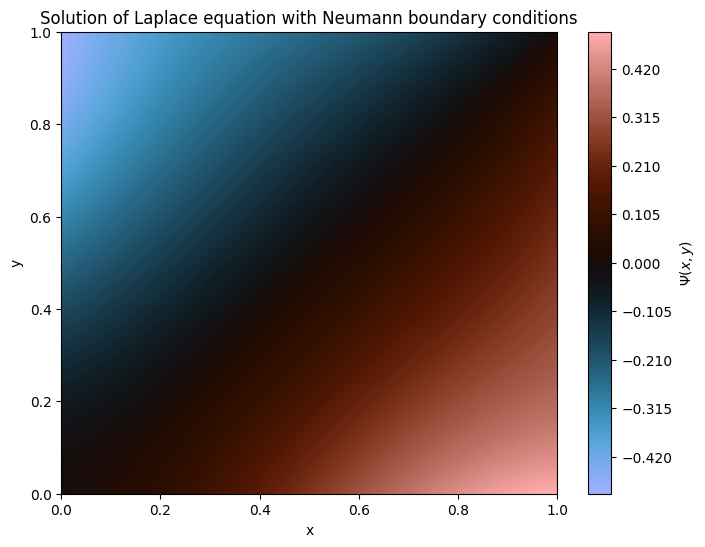

In [7]:
plot(x2, y2, Psi2)

In [8]:
# Comparing the methods
Psi2 - Psi1

array([[ 0.00000000e+00, -5.06089228e-08, -2.02410941e-07, ...,
        -8.10349320e-04, -8.10449306e-04, -8.10449306e-04],
       [ 5.06090983e-08,  1.11705095e-13, -1.51814409e-07, ...,
        -8.10349307e-04, -8.10449303e-04, -8.10449306e-04],
       [ 2.02411196e-07,  1.51814680e-07,  1.48940064e-13, ...,
        -8.10149341e-04, -8.10249339e-04, -8.10249352e-04],
       ...,
       [ 8.10349320e-04,  8.10349308e-04,  8.10149342e-04, ...,
         3.67420287e-13, -1.48168930e-07, -1.97550572e-07],
       [ 8.10449306e-04,  8.10449303e-04,  8.10249340e-04, ...,
         1.48169665e-07,  3.67421208e-13, -4.93873675e-08],
       [ 8.10449306e-04,  8.10449306e-04,  8.10249353e-04, ...,
         1.97551307e-07,  4.93881023e-08,  3.67421371e-13]],
      shape=(201, 201))

The analytical solution to the Laplace problem  

$$
\Delta\Psi = 0 \quad\text{in }[0,1]\times[0,1],\qquad \frac{\partial\Psi}{\partial n} = y\,n_x - x\,n_y \quad\text{on }\partial\Omega
$$

Is constructed as a sum of a particular polynomial and a Fourier series:

$$
\boxed{\;
\Psi(x,y) = (x-1)\,y 
+ \frac{8}{\pi^3} \sum_{\substack{n=1 \\ n\ \text{odd}}}^{\infty} 
\frac{1}{n^3}\,
\frac{\sinh\, \!\bigl(n\pi\,(y-\tfrac12)\bigr)}{\cosh\, \!\bigl(\tfrac{n\pi}{2}\bigr)}\,
\cos(n\pi x)
+ \frac{8}{\pi^3} \sum_{\substack{n=1 \\ n\ \text{odd}}}^{\infty} 
\frac{1}{n^3}\,
\tanh\, \!\Bigl(\frac{n\pi}{2}\Bigr) \;}
$$

In [9]:
# Analytical solution here
@jit(nopython = True, parallel = True)
def analytical_solution(N = 200, Nmax = 100, pin_zero = True):

    x = np.linspace(0, 1, N + 1)
    y = x.copy()
    Psi = np.zeros((N + 1, N + 1))

    # Polynomial part
    for i in range(N + 1):
        for j in range(N + 1):
            Psi[i, j] = (x[i] - 1) * y[j]

    # Fourier series part
    factor_base = 8 / (np.pi ** 3)

    for n in range(1, Nmax + 1, 2):
        a = n * np.pi
        denom = 1.0 + np.exp(-a) # 1 + e^{-nπ}
        coeff = factor_base / (n ** 3)

        # Loop over grid rows in parallel
        for i in range(N + 1):
            cos_val = np.cos(a * x[i]) # cos(nπ x_i)
            for j in range(N + 1):
                # Stable form of [sinh(nπ y) - tanh(nπ/2) cosh(nπ y)]
                exp_y1 = np.exp(a * (y[j] - 1.0)) # e^{nπ(y-1)}
                exp_y2 = np.exp(-a * y[j]) # e^{-nπ y}
                term_y = (exp_y1 - exp_y2) / denom

                Psi[i, j] += coeff * term_y * cos_val

    if pin_zero: # Add constant to enforce Psi(0,0) = 0 (if requested)
        C = 0.0
        for n in range(1, Nmax + 1, 2):
            a = n * np.pi
            C += factor_base / (n ** 3) * np.tanh(a * 0.5)

        for i in range(N + 1):
            for j in range(N + 1):
                Psi[i, j] += C

    return (x, y, Psi)

In [10]:
x3, y3, Psi3 = analytical_solution()
Psi3

array([[ 2.77555756e-17, -1.04154115e-04, -3.55715564e-04, ...,
        -4.99657184e-01, -4.99908745e-01, -5.00012899e-01],
       [ 8.93025877e-05, -6.68650985e-06, -2.42687540e-04, ...,
        -4.94770212e-01, -4.95006213e-01, -4.95102202e-01],
       [ 3.41153729e-04,  2.29374836e-04, -6.52218595e-06, ...,
        -4.90006377e-01, -4.90242274e-01, -4.90354053e-01],
       ...,
       [ 4.99645947e-01,  4.94757726e-01,  4.89993623e-01, ...,
        -6.52218595e-06, -4.77062516e-03, -9.65884627e-03],
       [ 4.99897798e-01,  4.94993787e-01,  4.90229788e-01, ...,
         4.75731246e-03, -6.68650985e-06, -4.91069741e-03],
       [ 4.99987101e-01,  4.95091255e-01,  4.90342816e-01, ...,
         9.64428444e-03,  4.89584589e-03,  2.77555756e-17]],
      shape=(201, 201))

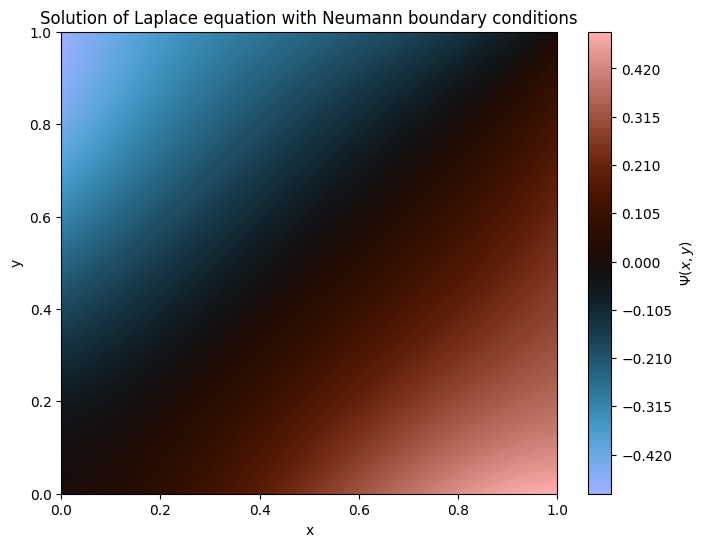

In [11]:
plot(x3, y3, Psi3)

In [12]:
# Comparison
Psi1 - Psi3, Psi2 - Psi3

(array([[-2.77555756e-17,  3.97120686e-06,  4.98390787e-06, ...,
          8.18467147e-04,  8.19428032e-04,  8.23348630e-04],
        [ 1.08803202e-05,  6.68650985e-06,  5.80078136e-06, ...,
          8.17599665e-04,  8.16662117e-04,  8.12417701e-04],
        [ 9.57792737e-06,  7.51192265e-06,  6.52218595e-06, ...,
          8.16526479e-04,  8.15484927e-04,  8.13368338e-04],
        ...,
        [-8.07230334e-04, -8.05113721e-04, -8.03772203e-04, ...,
          6.52218595e-06,  7.81190649e-06,  9.97788938e-06],
        [-8.08480911e-04, -8.04236489e-04, -8.02998983e-04, ...,
          5.50079752e-06,  6.68650985e-06,  1.09803169e-05],
        [-7.97549982e-04, -8.01470580e-04, -8.02131525e-04, ...,
          4.58394586e-06,  3.87121012e-06, -6.54858112e-17]],
       shape=(201, 201)),
 array([[-2.77555756e-17,  3.92059794e-06,  4.78149693e-06, ...,
          8.11782762e-06,  8.97872657e-06,  1.28993244e-05],
        [ 1.09309293e-05,  6.68650996e-06,  5.64896695e-06, ...,
          7.2